# Data Import

In [1]:
import pandas as pd
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath('..'))

from data.data import load_data

# Load the dataset
df = pd.read_csv("C:\\Users\\pc\\MLProjects\\Survival analysis\\survival-ml-system\\data\\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [2]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [3]:
import matplotlib.pyplot as plt

missing values in each column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
Visualize the distribution of a specific column


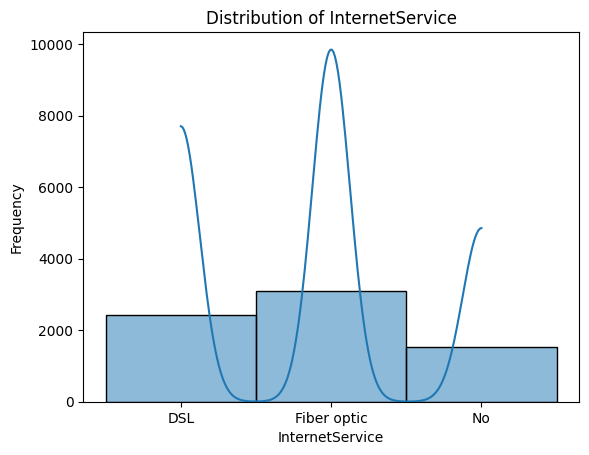

In [4]:
print("missing values in each column:")
print(df.isnull().sum())

print("Visualize the distribution of a specific column")
sns.histplot(df['InternetService'], kde=True)
plt.title('Distribution of InternetService')
plt.xlabel('InternetService')
plt.ylabel('Frequency')
plt.show()

Visualize the distribution of Churn


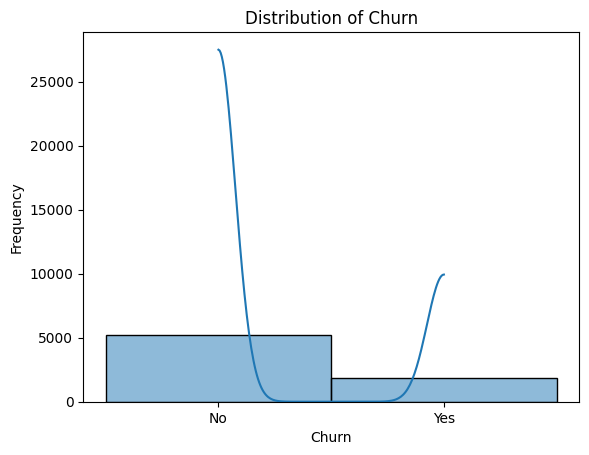

In [5]:
print("Visualize the distribution of Churn")
sns.histplot(df['Churn'], kde=True)
plt.title('Distribution of Churn')
plt.xlabel('Churn')
plt.ylabel('Frequency')
plt.show()

In [6]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [7]:
df['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [8]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [9]:
censored_percentage = df[df['Churn'] == 0].shape[0] / df.shape[0]
print(f"Censored percentage: {censored_percentage:.2%}")

Censored percentage: 73.46%


# Build intuition with EDA

## Churn vs Tenure

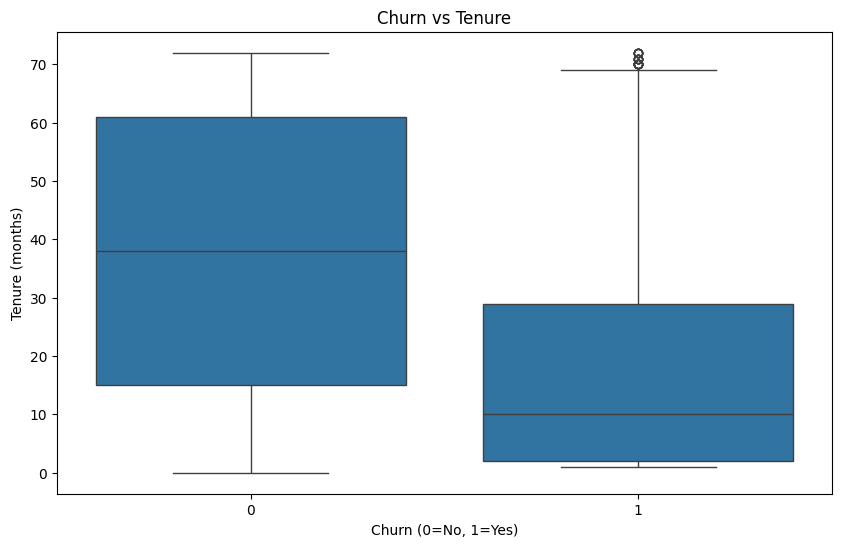

Correlation between Churn and Tenure: -0.3522


In [10]:
# Visualize the correlation between Churn and Tenure
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Churn vs Tenure')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Tenure (months)')
plt.show()

# Also show the correlation coefficient
correlation = df['Churn'].corr(df['tenure'])
print(f"Correlation between Churn and Tenure: {correlation:.4f}")

Correlation = -0.35
→ Moderate negative relationship
→ As tenure increases, churn decreases

Non-churned (0):
- Higher median tenure (~38 months)
- Wide spread → many long-term customers

Churned (1):
- Much lower median (~10 months)
- Most churn happens early

Interpretation:
- New customers are more likely to churn
- Long-term customers are more loyal
- There’s a clear time **dependency**

-> Customers who churn tend to have much lower tenure than those who don’t.

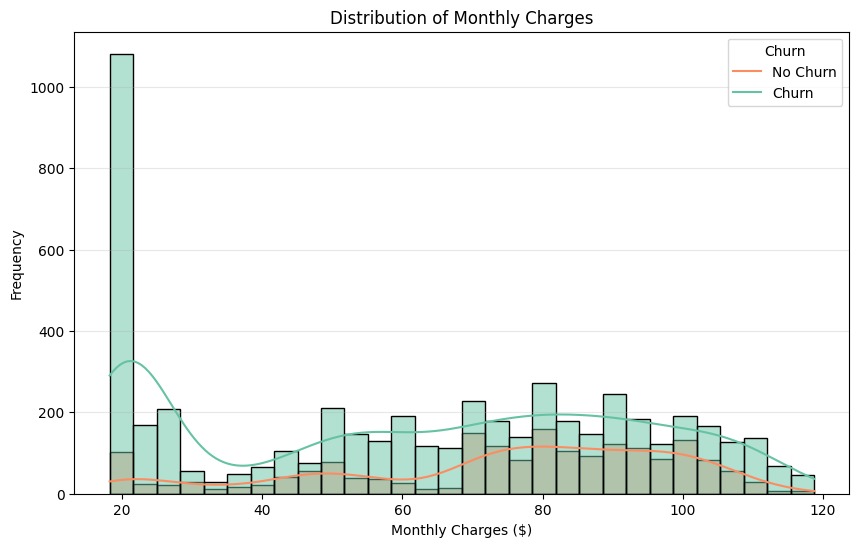

In [11]:
# Visualize the distribution of Monthly Charges
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, bins=30, palette='Set2')
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Frequency')
plt.legend(title='Churn', labels=['No Churn', 'Churn'])
plt.grid(axis='y', alpha=0.3)
plt.show()

Q: are expensive plans riskier? 
A: no, not necessarly, based on that plot, we notice that cx that churn have overall high monthly charges compared to loyal cx, also loyal customers seems to have high monthly charges on the expensive plans, compared to the cheaper ones. That said, expensive plans are not risky, in fact they're a positive factor

- Customer concentration at low prices: A large portion of customers sits around $20–25/month, forming the biggest segment.

- Churn appears higher at low prices (in absolute numbers): More churn cases are observed in the lowest price range. However, this is expected because most customers are in that segment.

- Higher-price segments show fewer churn cases: As monthly charges increase, the number of churners drops. But again, this may reflect fewer customers overall, not necessarily lower risk.

- Multiple pricing tiers: The distribution shows several peaks (~$50, ~$75–90), suggesting different subscription levels.

While churn counts are higher among low-cost plans, this is largely due to higher customer concentration in that segment. This plot alone does not confirm that expensive plans are less risky; churn rates by price segment are needed to draw that conclusion

In [12]:
df['MonthlyCharges'].unique()

array([29.85, 56.95, 53.85, ..., 63.1 , 44.2 , 78.7 ], shape=(1585,))

  MonthlyCharges_bin  total_customers  churned_customers  churn_percentage
0              $0-25             1389                127          9.143269
1             $25-50              905                234         25.856354
2             $50-75             1621                424         26.156693
3            $75-100             2220                827         37.252252
4           $100-125              908                257         28.303965


C:\Users\pc\AppData\Local\Temp\ipykernel_13264\2411574485.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_by_bin, x='MonthlyCharges_bin', y='churn_percentage', palette='Set2')


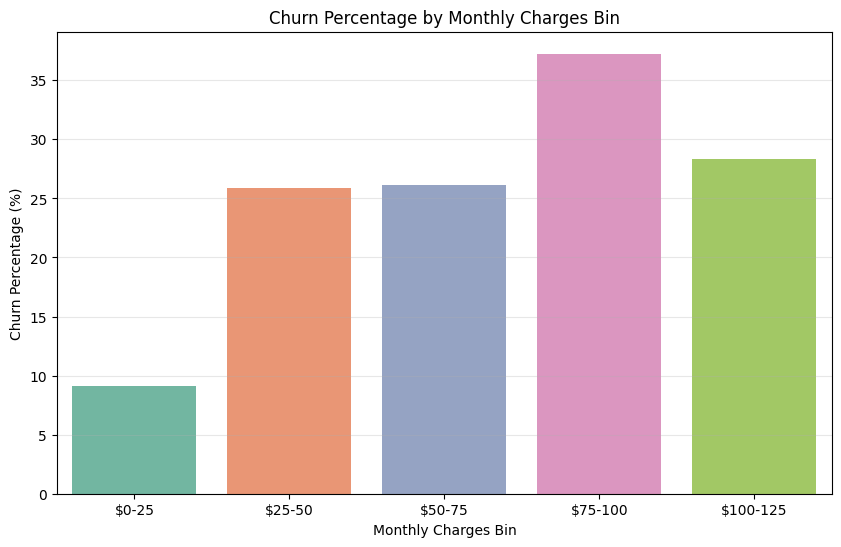

In [13]:
# Create bins for monthly charges and calculate churn percentage per bin
bins = [0, 25, 50, 75, 100, 125]
labels = ['$0-25', '$25-50', '$50-75', '$75-100', '$100-125']

df['MonthlyCharges_bin'] = pd.cut(df['MonthlyCharges'], bins=bins, labels=labels, right=False)

# Calculate churn percentage per bin
churn_by_bin = df.groupby('MonthlyCharges_bin', observed=True).agg(
    total_customers=('Churn', 'count'),
    churned_customers=('Churn', 'sum'),
    churn_percentage=('Churn', 'mean')
).reset_index()

churn_by_bin['churn_percentage'] = churn_by_bin['churn_percentage'] * 100

print(churn_by_bin)

# Visualize the churn percentage by bin
plt.figure(figsize=(10, 6))
sns.barplot(data=churn_by_bin, x='MonthlyCharges_bin', y='churn_percentage', palette='Set2')
plt.title('Churn Percentage by Monthly Charges Bin')
plt.xlabel('Monthly Charges Bin')
plt.ylabel('Churn Percentage (%)')
plt.grid(axis='y', alpha=0.3)
plt.show()

This graph shows that the highest churn percentage sits with the category 75$-100$, then 25-50$ and 100-125$ at the same level. The most risky plan is 75$-100$, and the safest one is 0-25$

1. Positive Correlation with Price: Churn rate increases dramatically with monthly charges:

- $0-25: ~9% (lowest churn)
- $25-50: ~26%
- $50-75: ~26%
- $75-100: ~37% (highest churn)
- $100-125: ~28%


2. Critical Risk Zone: The $75-100 segment has the highest churn risk at ~37%. These are high-value customers leaving at elevated rates—a significant business concern.

3. Low-Cost Stability: The $0-25 segment has the best retention (~9%), despite being the group with the most absolute churners in the previous chart. This reveals that low-cost customers churn in high numbers but at low rates (many customers, few leave).

3. High-Cost Vulnerability: Customers paying $75+ show churn rates 3-4x higher than low-cost customers. This suggests potential issues like:

- Price sensitivity among premium customers
- Unmet service expectations
- Better alternatives in that price range


Strategic Recommendations:

Focus on $75-100 segment: Investigate why high-value customers churn—this is where you lose most revenue
Upsell retention programs: When customers move from low to high tiers, implement better support/value messaging
Price positioning: Consider whether tier pricing is competitive in the $75-100 range

         Contract  total_customers  churned_customers  churn_percentage
0  Month-to-month             3875               1655         42.709677
1        One year             1473                166         11.269518
2        Two year             1695                 48          2.831858


C:\Users\pc\AppData\Local\Temp\ipykernel_13264\1837219307.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_by_contract, x='Contract', y='churn_percentage', palette='Set2')


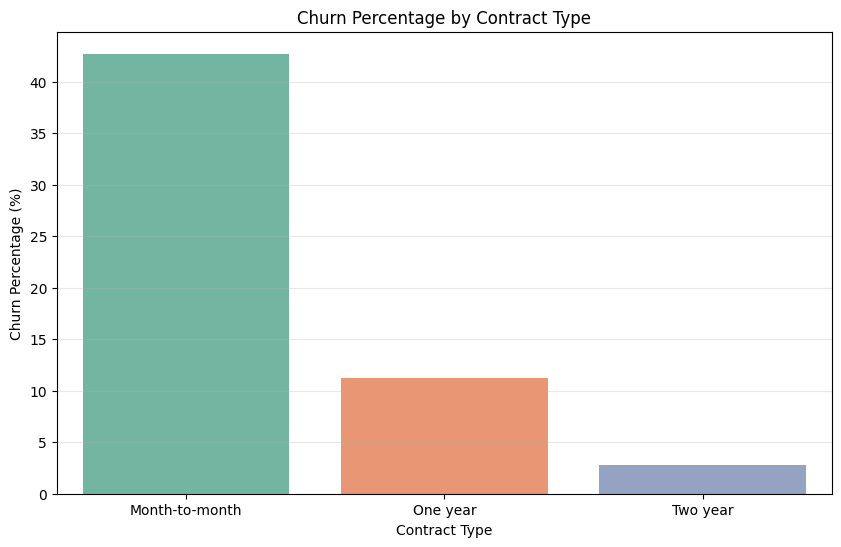

In [14]:
# Create bins for contract type and calculate churn percentage per contract type
churn_by_contract = df.groupby('Contract', observed=True).agg(
    total_customers=('Churn', 'count'),
    churned_customers=('Churn', 'sum'),
    churn_percentage=('Churn', 'mean')
).reset_index()

churn_by_contract['churn_percentage'] = churn_by_contract['churn_percentage'] * 100

print(churn_by_contract)

# Visualize the churn percentage by contract type
plt.figure(figsize=(10, 6))
sns.barplot(data=churn_by_contract, x='Contract', y='churn_percentage', palette='Set2')
plt.title('Churn Percentage by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Percentage (%)')
plt.grid(axis='y', alpha=0.3)
plt.show()

The less time in the contract, the higher the chance of churn for that customer

What kind of customers leave early?
- customers with short contract (especially month-to-month), with a 0.427 chance.
- customers that are enrolled in expensive plans, more than 75$, and also the ones between 25$ and 50$.
- customers with low tenure, customers who are new are more likely to churn.

# Data Preprocessing

In [15]:
# Load the data using the load_data function
from data.data import load_data
X, y = load_data("C:\\Users\\pc\\MLProjects\\Survival analysis\\survival-ml-system\\data\\WA_Fn-UseC_-Telco-Customer-Churn.csv")

Test


In [16]:
from data.data import split_data

X_train, X_test, y_train, y_test = split_data(X, y)

In [17]:
# Feature engineering
from src.features import add_features

X_train = add_features(X_train)
X_test = add_features(X_test)

dropped
dropped


In [18]:
# Preprocess the data
from src.preprocess import build_preprocessor

pre = build_preprocessor()

pre.fit(X_train)
X_train_pre = pre.transform(X_train)
X_test_pre = pre.transform(X_test)

# Train

## Model 1 + 2: Kaplan-Meier and Cox P

In [19]:
# Fit Kaplan-Meier estimator
from models.km_cox import fit_kaplan_meier

kmf = fit_kaplan_meier(y_train,"km_curve.png")

KM median survival: inf months


In [20]:
# Fit Cox Proportional Hazards model
from models.km_cox import fit_cox

cox_model = fit_cox(X_train_pre, y_train)

In [21]:
# Evaluate Cox (C-index)
from models.km_cox import c_index

train_score = c_index(cox_model, X_train_pre, y_train)
test_score = c_index(cox_model, X_test_pre, y_test)

print("Train C-index:", train_score)
print("Test C-index:", test_score)

Train C-index: 0.99089882341369
Test C-index: 0.9900645139546184


In [22]:
import numpy as np

print("Event rate:", np.mean(y_train["event"]))

Event rate: 0.2657777777777778


## Random Survival Forest

In [23]:
# Train RSF model
from models.rsf import fit_rsf

rsf_model = fit_rsf(X_train_pre, y_train)

In [24]:
# Compute C-index for RSF
from sksurv.metrics import concordance_index_censored

# Train C-index
train_risk = rsf_model.predict(X_train_pre)
train_cindex = concordance_index_censored(
    y_train["event"], y_train["duration"], train_risk
)[0]

# Test C-index
test_risk = rsf_model.predict(X_test_pre)
test_cindex = concordance_index_censored(
    y_test["event"], y_test["duration"], test_risk
)[0]

print("RSF Train C-index:", train_cindex)
print("RSF Test C-index:", test_cindex)

RSF Train C-index: 0.8974860205175855
RSF Test C-index: 0.8851626330231683


In [25]:
import models.rsf

In [26]:
# Compute IBS (Integrated Brier Score)
from models.rsf import integrated_brier

ibs = integrated_brier(rsf_model, X_test_pre, y_train, y_test)

print("RSF IBS:", ibs)

RSF IBS: 0.029729665069929658


C-index:
-> ranking quality (who churns earlier)

- higher = better
- compare with Cox

IBS
-> probability calibration over time

- lower = better
- ~0.25 = useless model

“The Random Survival Forest achieved a C-index of ~0.88 on the test set, significantly outperforming the Cox model. This indicates strong ability to rank churn risk. The IBS was very low (~0.03), showing accurate survival probability estimates over time.”

Why RSF worked well?

“RSF captures non-linear interactions between features like contract type, charges, and tenure-derived signals, which Cox PH cannot model due to its linear assumption.”

In [27]:
import joblib

joblib.dump(rsf_model, "C:\\Users\\pc\\MLProjects\\Survival analysis\\survival-ml-system\\models\\rsf.pkl")
joblib.dump(pre, "C:\\Users\pc\\MLProjects\\Survival analysis\\survival-ml-system\\models\\preprocessor.pkl")

<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\p'
C:\Users\pc\AppData\Local\Temp\ipykernel_13264\1432937100.py:4: SyntaxWarning: invalid escape sequence '\p'
  joblib.dump(pre, "C:\\Users\pc\\MLProjects\\Survival analysis\\survival-ml-system\\models\\preprocessor.pkl")


['C:\\Users\\pc\\MLProjects\\Survival analysis\\survival-ml-system\\models\\preprocessor.pkl']

## Deepsurv

In [28]:
from models.deepsurv import train_deepsurv


deepsurv_model = train_deepsurv(
    X_train_pre,
    y_train,
    epochs=50,
    lr=1e-3
)

Epoch 10/50  loss=7.9454
Epoch 20/50  loss=7.6644
Epoch 30/50  loss=7.2395
Epoch 40/50  loss=6.7730
Epoch 50/50  loss=6.4266


In [29]:
# Get risk scores on test set
from models.deepsurv import predict_risk

risk_test = predict_risk(deepsurv_model, X_test_pre)

In [30]:
# compute C-index for DeepSurv
from sksurv.metrics import concordance_index_censored

cindex = concordance_index_censored(
    y_test["event"],
    y_test["duration"],
    risk_test
)[0]

print("DeepSurv Test C-index:", cindex)

DeepSurv Test C-index: 0.9584787963386856


In [31]:
# Train C-index (to check overfitting)
risk_train = predict_risk(deepsurv_model, X_train_pre)

train_cindex = concordance_index_censored(
    y_train["event"],
    y_train["duration"],
    risk_train
)[0]

print("DeepSurv Train C-index:", train_cindex)

DeepSurv Train C-index: 0.9597121284909185


# Evaluation

In [32]:
from src.evaluate import score_model
risk_rsf = rsf_model.predict(X_test_pre)
score_model("Random Survival Forest", risk_rsf, y_test)

Random Survival Forest    | C-index: 0.885


np.float64(0.8851626330231683)

In [33]:
risk_cox = cox_model.predict(X_test_pre)
score_model("Cox PH", risk_cox, y_test)

Cox PH                    | C-index: 0.990


np.float64(0.9900645139546184)

## Results

| Model                  | C-index (test) | IBS ↓  | Notes                        |
|------------------------|---------------|--------|------------------------------|
| Kaplan-Meier           | —             | —      | Baseline, no features        |
| Cox PH                 | 0.990         | —      | Linear, interpretable        |
| Random Survival Forest | 0.885 | 0.029 | Best model, non-linear       |
| DeepSurv               | 0.958         | —      | Neural log-hazard            |


In [ ]:
print("tt")

tt


: 